# Quantum flavor-mode correlations

This notebook first introduces the effect with two flavors, where every quantity can be read directly from the oscillation probabilities. It then applies the same construction to the T2K-like three-flavor vacuum example from `01_vacuum_pmns_examples.ipynb`.

The oscillation probabilities are unchanged. The new API retains the complex state amplitudes, allowing us to build a density matrix and quantify correlations between flavor modes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repoRoot = Path.cwd()
if not (repoRoot / 'src').exists():
    repoRoot = repoRoot.parent
sys.path.insert(0, str(repoRoot / 'src'))

from nu_waves.correlations import GaussianWavePacket, flavor_mode_correlations
from nu_waves.hamiltonian import vacuum
from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.propagation.oscillator import Oscillator
from nu_waves.utils import flavors
from nu_waves.utils import style


## 1. Two flavors: a single-neutrino Bell-like state

An initially electron-flavor neutrino evolves as $|\nu_e(L)\rangle=a_{ee}|10\rangle_{e\mu}+a_{e\mu}|01\rangle_{e\mu}$. The two flavor modes are maximally correlated when $P_{ee}=P_{e\mu}=1/2$.

For this pure two-mode state, the linear entropy and the concurrence are $S_L=4P_{ee}P_{e\mu}$ and $C_{e\mu}=2\sqrt{P_{ee}P_{e\mu}}$.

In [2]:
twoFlavorOscillator = Oscillator(vacuum.Hamiltonian(
    mixing=Mixing(n_neutrinos=2, mixing_angles={(1, 2): np.pi / 4}),
    spectrum=Spectrum(n_neutrinos=2, dm2={(2, 1): 2.42e-3}),
    antineutrino=False,
))

twoFlavorBaseline = np.linspace(0.0, 2000.0, 800)
twoFlavorEnergy = 0.6  # GeV
twoFlavorProbability = twoFlavorOscillator.probability(
    L_km=twoFlavorBaseline,
    E_GeV=twoFlavorEnergy,
    flavor_emit=flavors.electron,
    flavor_det=[flavors.electron, flavors.muon],
)
# Preserve amplitudes as rho = |nu(L)><nu(L)| instead of keeping probabilities only.
twoFlavorRho = twoFlavorOscillator.density_matrix(
    L_km=twoFlavorBaseline, E_GeV=twoFlavorEnergy, flavor_emit=flavors.electron
)[:, 0]
# Convert rho into flavor populations, one-mode entropies, and pairwise concurrences.
twoFlavorMetrics = flavor_mode_correlations(twoFlavorRho)
np.testing.assert_allclose(twoFlavorMetrics.populations, twoFlavorProbability, atol=1e-12)


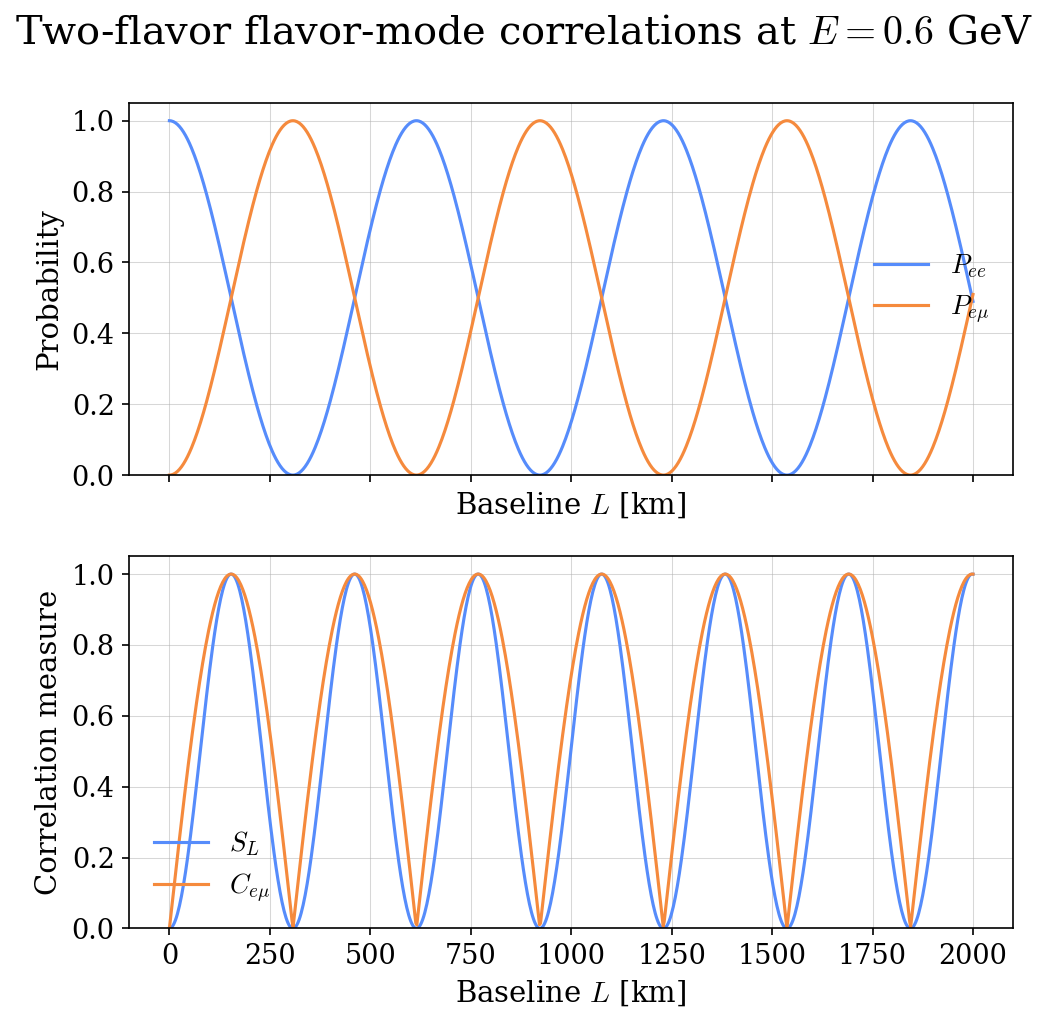

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
axes[0].plot(twoFlavorBaseline, twoFlavorProbability[:, flavors.electron], label=r'$P_{ee}$')
axes[0].plot(twoFlavorBaseline, twoFlavorProbability[:, flavors.muon], label=r'$P_{e\mu}$')
axes[0].set_ylabel('Probability')
axes[0].set_ylim(0, 1.05)
axes[0].legend(frameon=False)

axes[1].plot(twoFlavorBaseline, twoFlavorMetrics.linear_entropy[:, flavors.electron], label=r'$S_L$')
axes[1].plot(twoFlavorBaseline, twoFlavorMetrics.pairwise_concurrence[:, flavors.electron, flavors.muon], label=r'$C_{e\mu}$')
axes[1].set_ylabel('Correlation measure')
axes[1].set_ylim(0, 1.05)
axes[1].legend(frameon=False)

for axis in axes:
    axis.set_xlabel(r'Baseline $L$ [km]')
    axis.grid()
fig.suptitle(r'Two-flavor flavor-mode correlations at $E=0.6$ GeV')
fig.tight_layout()


The peaks of $S_L$ and $C_{e\mu}$ occur where neither flavor can be assigned with certainty. They are therefore a phase-sensitive characterization of the same interference that generates flavor appearance and disappearance.

## 2. T2K-like three-flavor example

For an initially muon-flavor neutrino, the single-excitation encoding is $a_e|100\rangle+a_\mu|010\rangle+a_\tau|001\rangle$. The linear entropy of one mode quantifies its correlation with the other two modes; the concurrence quantifies the correlation of a selected pair after tracing out the third one.

In [4]:
angles = {(1, 2): np.deg2rad(33.4), (1, 3): np.deg2rad(8.6), (2, 3): np.deg2rad(49.0)}
phases = {(1, 3): np.deg2rad(195.0)}
massSplittings = {(2, 1): 7.42e-5, (3, 2): 2.4428e-3}
t2kOscillator = Oscillator(vacuum.Hamiltonian(
    mixing=Mixing(3, mixing_angles=angles, dirac_phases=phases),
    spectrum=Spectrum(3, m_lightest=0.0, dm2=massSplittings),
    antineutrino=False,
))

t2kBaseline = 295.0
energy = np.linspace(0.2, 3.0, 800)
t2kProbability = t2kOscillator.probability(
    t2kBaseline, energy, flavors.muon, [flavors.electron, flavors.muon, flavors.tau]
)
# The density matrix retains the relative phases between e, mu, and tau amplitudes.
t2kRho = t2kOscillator.density_matrix(t2kBaseline, energy, flavor_emit=flavors.muon)[:, 0]
# Correlations are evaluated in the single-neutrino flavor-mode encoding.
t2kMetrics = flavor_mode_correlations(t2kRho)
np.testing.assert_allclose(t2kMetrics.populations, t2kProbability, atol=1e-12)


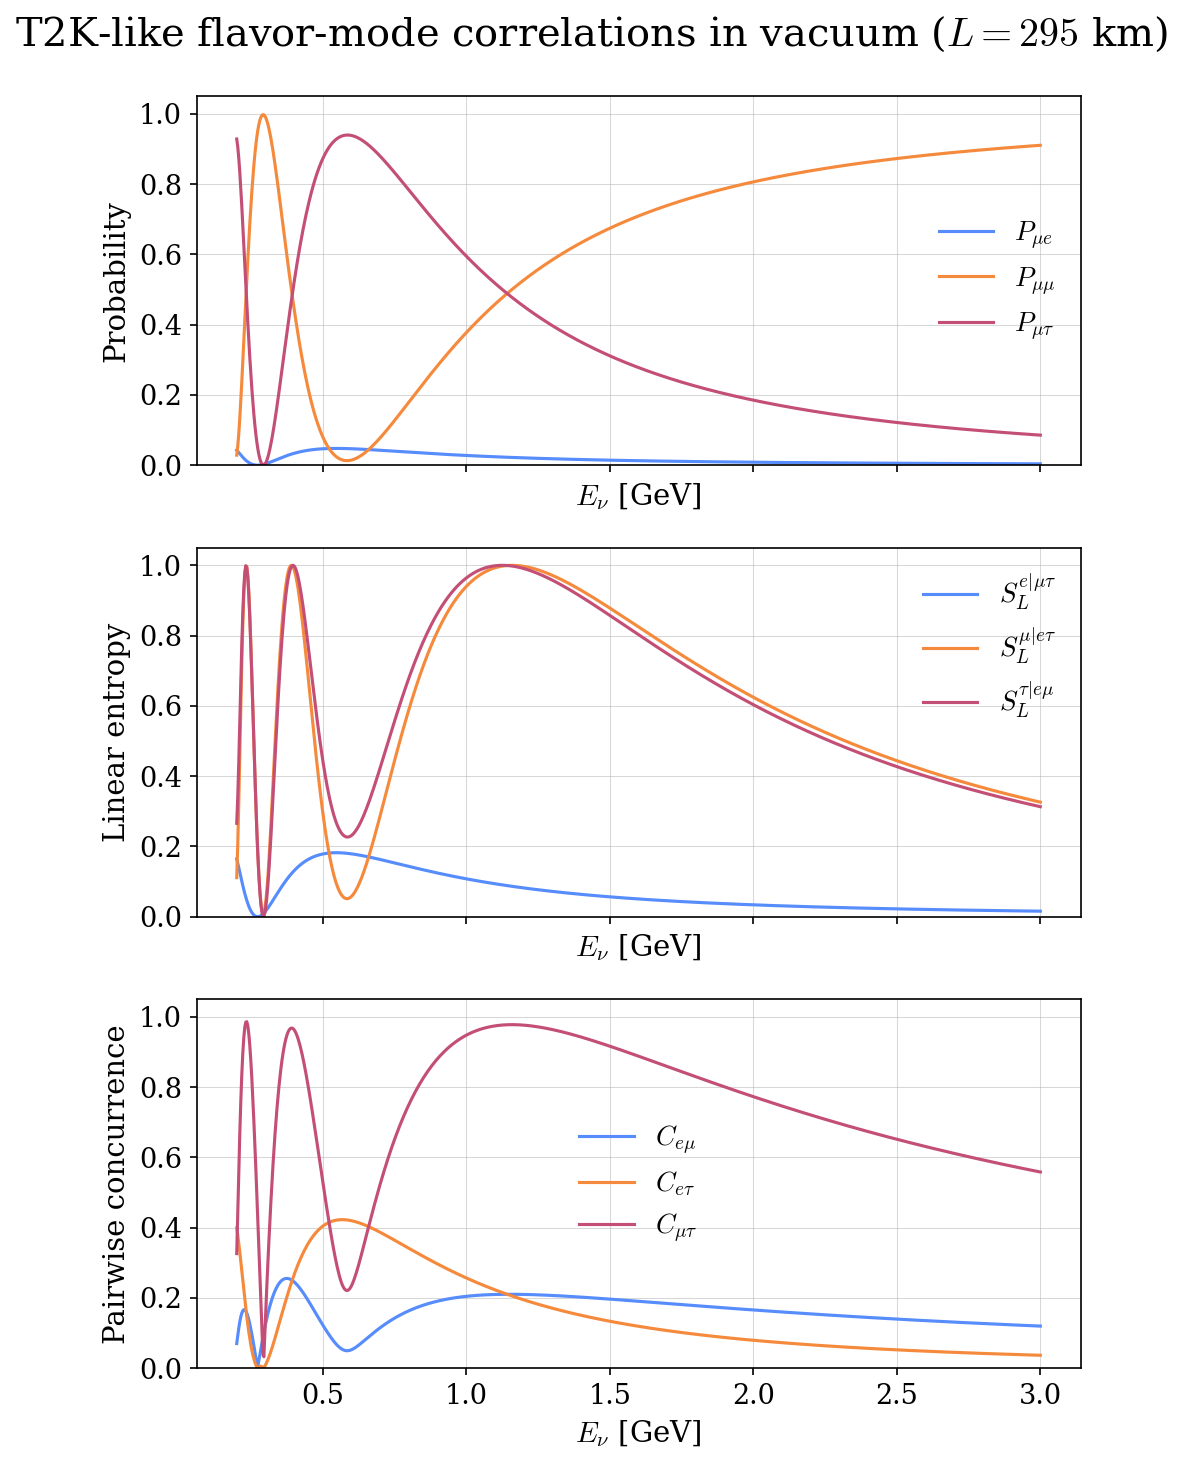

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(7, 10), sharex=True)
axes[0].plot(energy, t2kProbability[:, flavors.electron], label=r'$P_{\mu e}$')
axes[0].plot(energy, t2kProbability[:, flavors.muon], label=r'$P_{\mu\mu}$')
axes[0].plot(energy, t2kProbability[:, flavors.tau], label=r'$P_{\mu\tau}$')
axes[0].set_ylabel('Probability')

axes[1].plot(energy, t2kMetrics.linear_entropy[:, flavors.electron], label=r'$S_L^{e|\mu\tau}$')
axes[1].plot(energy, t2kMetrics.linear_entropy[:, flavors.muon], label=r'$S_L^{\mu|e\tau}$')
axes[1].plot(energy, t2kMetrics.linear_entropy[:, flavors.tau], label=r'$S_L^{\tau|e\mu}$')
axes[1].set_ylabel('Linear entropy')

axes[2].plot(energy, t2kMetrics.pairwise_concurrence[:, flavors.electron, flavors.muon], label=r'$C_{e\mu}$')
axes[2].plot(energy, t2kMetrics.pairwise_concurrence[:, flavors.electron, flavors.tau], label=r'$C_{e\tau}$')
axes[2].plot(energy, t2kMetrics.pairwise_concurrence[:, flavors.muon, flavors.tau], label=r'$C_{\mu\tau}$')
axes[2].set_ylabel('Pairwise concurrence')

for axis in axes:
    axis.set_xlabel(r'$E_\nu$ [GeV]')
    axis.set_ylim(0, 1.05)
    axis.grid()
    axis.legend(frameon=False)
fig.suptitle(r'T2K-like flavor-mode correlations in vacuum ($L=295$ km)')
fig.tight_layout()


## 3. Optional wave-packet decoherence

`GaussianWavePacket` damps off-diagonal mass-basis elements while preserving the trace. The small width below is deliberately illustrative: a phenomenological analysis must use a width motivated by the production and detection processes.

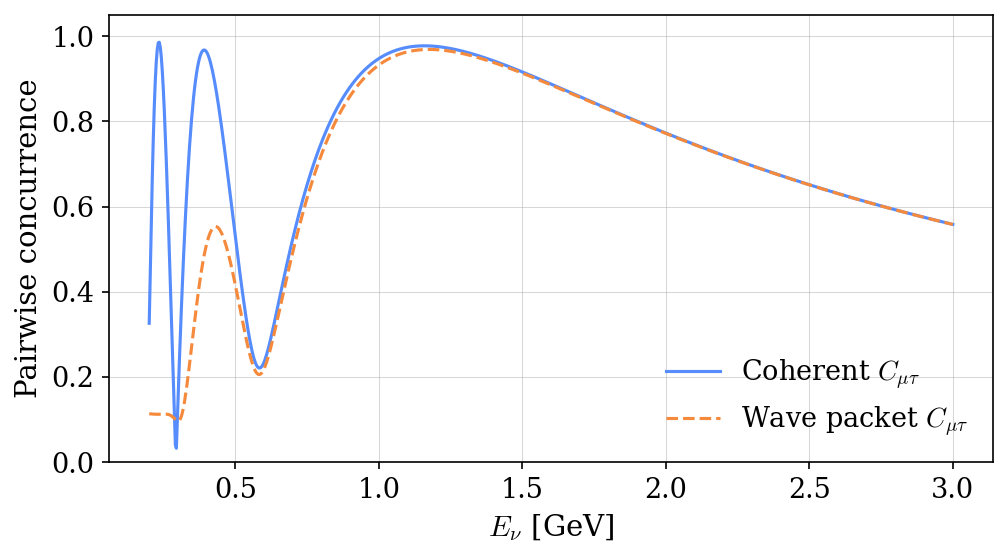

In [6]:
wavePacket = GaussianWavePacket(sigma_x_m=1e-15)
decoheredRho = t2kOscillator.density_matrix(
    t2kBaseline, energy, flavors.muon, coherence_model=wavePacket
)[:, 0]
# Apply the same correlation analysis after the wave-packet decoherence channel.
decoheredMetrics = flavor_mode_correlations(decoheredRho)

plt.figure(figsize=(7, 4))
plt.plot(energy, t2kMetrics.pairwise_concurrence[:, flavors.muon, flavors.tau], label=r'Coherent $C_{\mu\tau}$')
plt.plot(energy, decoheredMetrics.pairwise_concurrence[:, flavors.muon, flavors.tau], '--', label=r'Wave packet $C_{\mu\tau}$')
plt.xlabel(r'$E_\nu$ [GeV]')
plt.ylabel('Pairwise concurrence')
plt.ylim(0, 1.05)
plt.grid()
plt.legend(frameon=False)
plt.tight_layout()
